# Customer Churn Analysis — Telco Dataset

**Goal:** predict which customers are likely to cancel their service (churn), identify the customer segments **associated with** higher churn risk, and produce outputs that can be visualized in Power BI.

> A note on language: This is observational data, not a controlled experiment — so when a segment shows higher churn, that's a correlation, not a proven cause. I've tried to stick to "associated with churn" / "risk factor" instead of "causes churn" throughout this notebook.

**Dataset:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7,043 customers, 21 columns, target column `Churn` (Yes/No).

**Workflow:**
1. Load the data
2. Inspect it (shape, types, missing values, duplicates, target balance)
3. Clean it
4. Exploratory Data Analysis (EDA) — single-variable patterns + interaction analysis
5. Prepare data for modeling (`ColumnTransformer` + `Pipeline`)
6. Build models (Logistic Regression + Random Forest)
7. Evaluate models, including a **decision threshold analysis**
8. Feature importance
9. Justify the final model choice with evidence
10. Export two separate outputs for Power BI: an **evaluation** dataset and a **business scoring** dataset


## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)


## 1. Load the data

In [2]:
dir = os.getcwd()
df = pd.read_csv(f"{dir}\\data\\telco_churn.csv")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(3)


Shape: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 2. Inspect the data

Checking: column types, missing values, duplicates, and target balance (this last one determines which metrics matter later).

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
blank_mask = df["TotalCharges"].str.strip() == ""
print(f"Blank TotalCharges entries: {blank_mask.sum()}")
df.loc[blank_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]].head()


Blank TotalCharges entries: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,


All blank `TotalCharges` rows have `tenure == 0` — new customers not yet billed. Logical, not random — straightforward to fix.

In [5]:
print("Duplicate customerIDs:", df["customerID"].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())
print()
print(df["Churn"].value_counts(normalize=True).round(3))


Duplicate customerIDs: 0
Fully duplicate rows: 0

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


**Target is imbalanced: ~73.5% No / 26.5% Yes.** We'll stratify the split and lean on precision/recall/F1 rather than raw accuracy.

In [6]:
cat_cols = df.select_dtypes(include="object").columns.drop(["customerID", "TotalCharges", "Churn"])
for c in cat_cols:
    print(f"{c}: {df[c].unique().tolist()}")


gender: ['Female', 'Male']
Partner: ['Yes', 'No']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No phone service', 'No', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'Yes', 'No internet service']
OnlineBackup: ['Yes', 'No', 'No internet service']
DeviceProtection: ['No', 'Yes', 'No internet service']
TechSupport: ['No', 'Yes', 'No internet service']
StreamingTV: ['No', 'Yes', 'No internet service']
StreamingMovies: ['No', 'Yes', 'No internet service']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['Yes', 'No']
PaymentMethod: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']


C:\Users\Gouja\AppData\Local\Temp\ipykernel_23044\351516537.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.drop(["customerID", "TotalCharges", "Churn"])


`"No internet service"` / `"No phone service"` are redundant with `InternetService == "No"` / `PhoneService == "No"` — collapsed to `"No"` in cleaning.

## 3. Clean the data

1. `TotalCharges` → numeric, blanks (tenure=0) → 0.
2. Collapse redundant "No internet/phone service" categories to "No".
3. `customerID` stays out of the model features but is kept for the exports.

In [7]:
data = df.copy()

data["TotalCharges"] = pd.to_numeric(data["TotalCharges"].str.strip(), errors="coerce")
data["TotalCharges"] = data["TotalCharges"].fillna(0)

service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies"]
for c in service_cols:
    data[c] = data[c].replace("No internet service", "No")
data["MultipleLines"] = data["MultipleLines"].replace("No phone service", "No")

for c in service_cols + ["MultipleLines"]:
    assert "No internet service" not in data[c].unique()
    assert "No phone service" not in data[c].unique()

data["ChurnFlag"] = (data["Churn"] == "Yes").astype(int)
print("Cleaning done. Shape:", data.shape)


Cleaning done. Shape: (7043, 22)


## 4. Exploratory Data Analysis (EDA)

First we'll look at individual variables, then check a few combinations to see whether the patterns change.


In [8]:
overall_rate = data["ChurnFlag"].mean()
print(f"Finding: overall churn rate is {overall_rate:.1%}.")


Finding: overall churn rate is 26.5%.


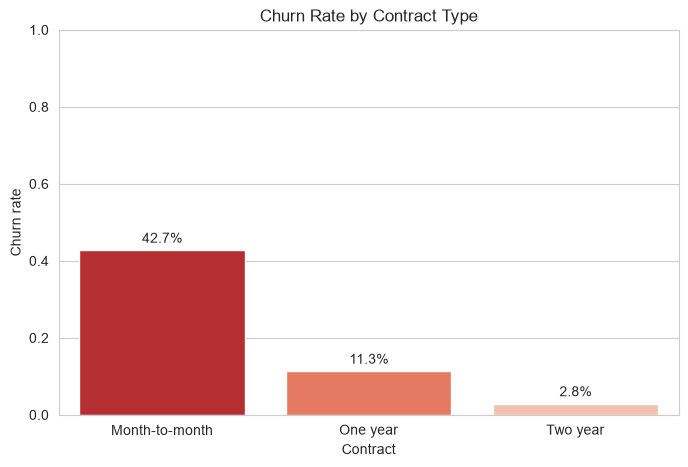

Finding: month-to-month customers churn at 42.7%, vs 11.3% for one-year and 2.8% for two-year contracts.


In [9]:
contract_churn = data.groupby("Contract")["ChurnFlag"].mean().reindex(["Month-to-month", "One year", "Two year"])

plt.figure()
sns.barplot(x=contract_churn.index, y=contract_churn.values, hue=contract_churn.index, palette="Reds_r", legend=False)
plt.ylabel("Churn rate")
plt.title("Churn Rate by Contract Type")
plt.ylim(0, 1)
for i, v in enumerate(contract_churn.values):
    plt.text(i, v + 0.02, f"{v:.1%}", ha="center")
plt.show()

print(f"Finding: month-to-month customers churn at {contract_churn['Month-to-month']:.1%}, "
      f"vs {contract_churn['One year']:.1%} for one-year and {contract_churn['Two year']:.1%} for two-year contracts.")


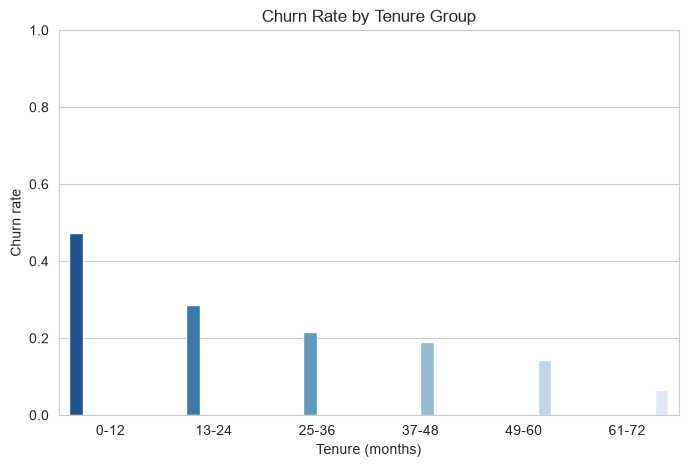

Finding: churn is 47.4% in the first 0-12 months, falling to 6.6% for customers at 61-72 months tenure.


In [10]:
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
data["TenureGroup"] = pd.cut(data["tenure"], bins=bins, labels=labels, include_lowest=True)

tenure_churn = data.groupby("TenureGroup", observed=True)["ChurnFlag"].mean()

plt.figure()
sns.barplot(x=tenure_churn.index, y=tenure_churn.values, hue=tenure_churn.index, palette="Blues_r", legend=False)
plt.ylabel("Churn rate")
plt.xlabel("Tenure (months)")
plt.title("Churn Rate by Tenure Group")
plt.ylim(0, 1)
plt.show()

print(f"Finding: churn is {tenure_churn.iloc[0]:.1%} in the first 0-12 months, "
      f"falling to {tenure_churn.iloc[-1]:.1%} for customers at 61-72 months tenure.")


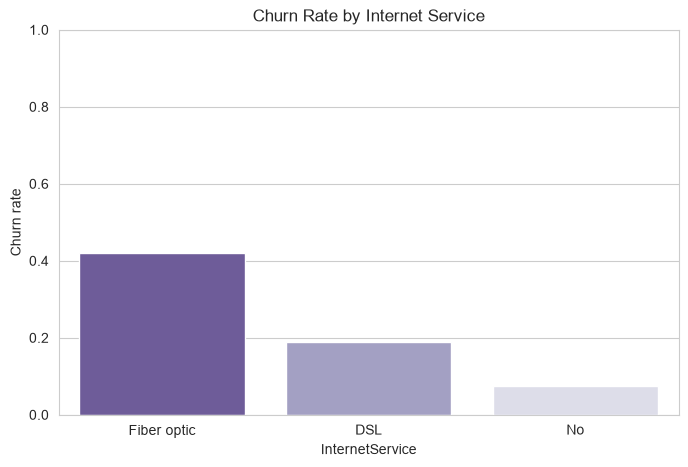

Finding: fiber optic customers churn at 41.9%, vs 19.0% for DSL and 7.4% for no internet service.


In [11]:
internet_churn = data.groupby("InternetService")["ChurnFlag"].mean().sort_values(ascending=False)

plt.figure()
sns.barplot(x=internet_churn.index, y=internet_churn.values, hue=internet_churn.index, palette="Purples_r", legend=False)
plt.ylabel("Churn rate")
plt.title("Churn Rate by Internet Service")
plt.ylim(0, 1)
plt.show()

print(f"Finding: fiber optic customers churn at {internet_churn.get('Fiber optic', float('nan')):.1%}, "
      f"vs {internet_churn.get('DSL', float('nan')):.1%} for DSL and {internet_churn.get('No', float('nan')):.1%} for no internet service.")


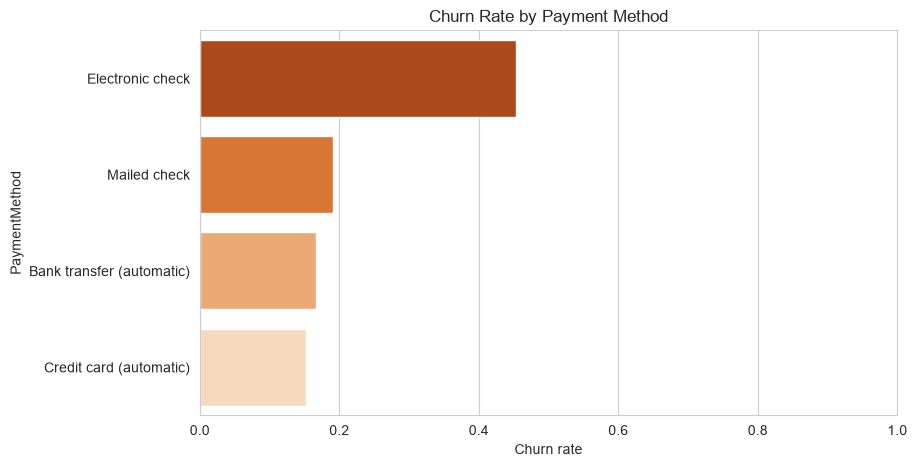

Finding: Electronic check has the highest churn rate at 45.3%, vs 15.2% for Credit card (automatic).


In [12]:
payment_churn = data.groupby("PaymentMethod")["ChurnFlag"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=payment_churn.values, y=payment_churn.index, hue=payment_churn.index, palette="Oranges_r", legend=False)
plt.xlabel("Churn rate")
plt.title("Churn Rate by Payment Method")
plt.xlim(0, 1)
plt.show()

print(f"Finding: {payment_churn.index[0]} has the highest churn rate at {payment_churn.iloc[0]:.1%}, "
      f"vs {payment_churn.iloc[-1]:.1%} for {payment_churn.index[-1]}.")


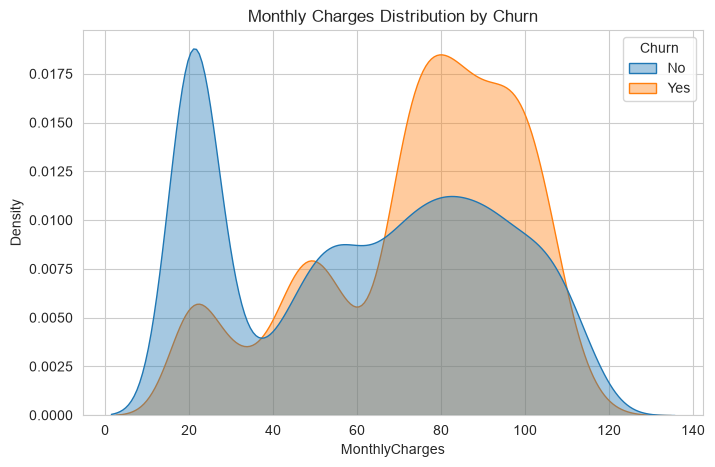

Finding: churned customers average $74.44/month vs $61.27/month for retained customers.


In [13]:
plt.figure()
sns.kdeplot(data=data, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False, alpha=0.4)
plt.title("Monthly Charges Distribution by Churn")
plt.show()

print(f"Finding: churned customers average ${data.loc[data['Churn']=='Yes','MonthlyCharges'].mean():.2f}/month "
      f"vs ${data.loc[data['Churn']=='No','MonthlyCharges'].mean():.2f}/month for retained customers.")


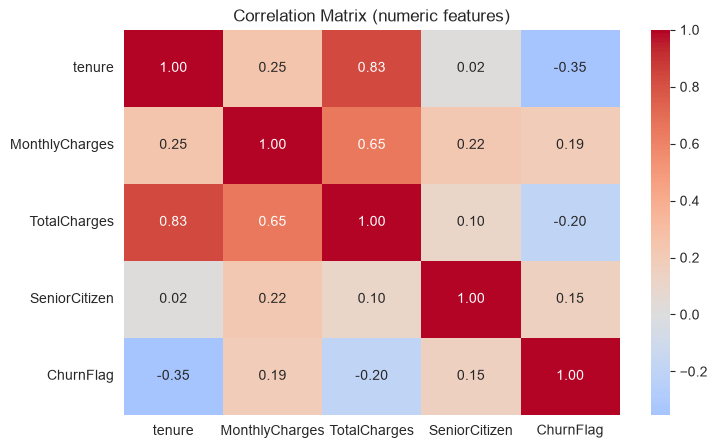

In [14]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "ChurnFlag"]
corr = data[numeric_cols].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix (numeric features)")
plt.show()


### Interaction analysis

Single-variable views can be misleading if the variables are correlated with each other (e.g. fiber customers skew month-to-month). These three interaction views check whether the single-variable patterns hold up once we segment by a second factor.

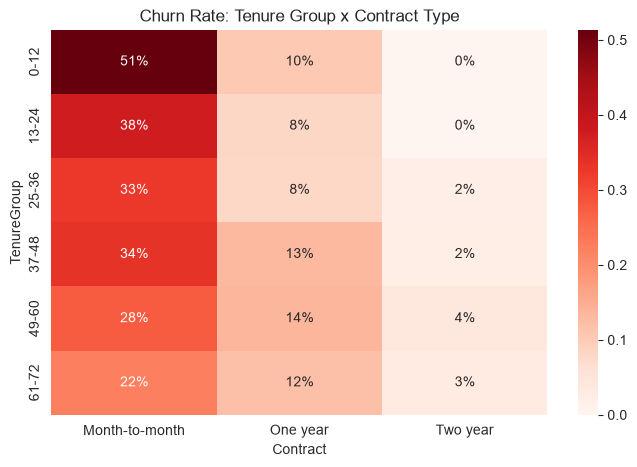

Finding: within month-to-month contracts alone, churn is 51.4% in months 0-12 vs 22.2% at 61-72 months -- so the tenure effect holds even after controlling for contract type. Early tenure isn't just a proxy for being on a month-to-month plan.


In [15]:
# Interaction 1: Contract x Tenure -- is early-tenure churn specifically a month-to-month problem?
pivot1 = data.pivot_table(index="TenureGroup", columns="Contract", values="ChurnFlag",
                           aggfunc="mean", observed=True).reindex(columns=["Month-to-month", "One year", "Two year"])

plt.figure(figsize=(8, 5))
sns.heatmap(pivot1, annot=True, fmt=".0%", cmap="Reds")
plt.title("Churn Rate: Tenure Group x Contract Type")
plt.show()

mtm_early = pivot1.loc["0-12", "Month-to-month"]
mtm_late = pivot1.loc["61-72", "Month-to-month"]
print(f"Finding: within month-to-month contracts alone, churn is {mtm_early:.1%} in months 0-12 "
      f"vs {mtm_late:.1%} at 61-72 months -- so the tenure effect holds even after controlling for contract type. "
      f"Early tenure isn't just a proxy for being on a month-to-month plan.")


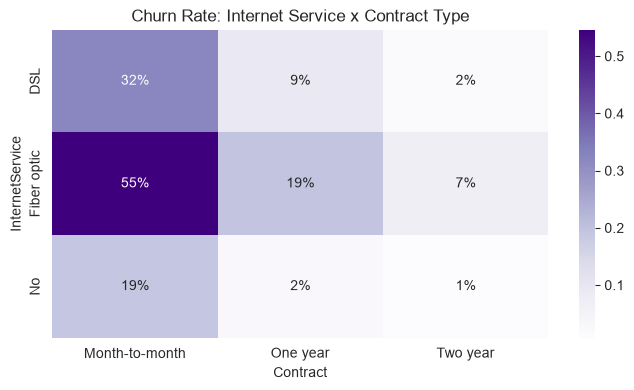

Finding: within month-to-month contracts, fiber optic customers churn at 54.6% vs 32.2% for DSL -- fiber's elevated churn is not just a contract-type artifact, it persists within the same contract segment.


In [16]:
# Interaction 2: Contract x Internet Service -- is fiber's high churn still visible within each contract type?
pivot2 = data.pivot_table(index="InternetService", columns="Contract", values="ChurnFlag",
                           aggfunc="mean").reindex(columns=["Month-to-month", "One year", "Two year"])

plt.figure(figsize=(8, 4))
sns.heatmap(pivot2, annot=True, fmt=".0%", cmap="Purples")
plt.title("Churn Rate: Internet Service x Contract Type")
plt.show()

fiber_mtm = pivot2.loc["Fiber optic", "Month-to-month"]
dsl_mtm = pivot2.loc["DSL", "Month-to-month"]
print(f"Finding: within month-to-month contracts, fiber optic customers churn at {fiber_mtm:.1%} "
      f"vs {dsl_mtm:.1%} for DSL -- fiber's elevated churn is not just a contract-type artifact, "
      f"it persists within the same contract segment.")


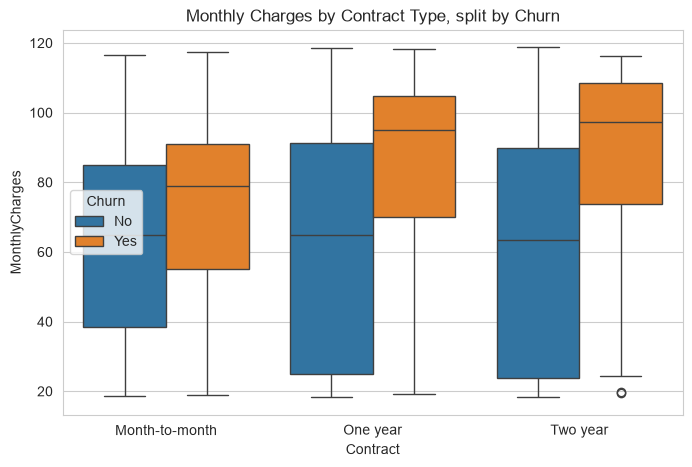

Month-to-month: churned avg $73.02 vs retained avg $61.46
One year: churned avg $85.05 vs retained avg $62.51
Two year: churned avg $86.78 vs retained avg $60.01

Finding: within every contract type, churned customers pay more per month on average than retained customers -- monthly charges carry signal beyond just being a stand-in for contract type.


In [17]:
# Interaction 3: are high monthly charges just a proxy for contract/service type, or a signal on their own?
plt.figure()
sns.boxplot(data=data, x="Contract", y="MonthlyCharges", hue="Churn",
            order=["Month-to-month", "One year", "Two year"])
plt.title("Monthly Charges by Contract Type, split by Churn")
plt.show()

for c in ["Month-to-month", "One year", "Two year"]:
    sub = data[data["Contract"] == c]
    yes_mean = sub.loc[sub["Churn"] == "Yes", "MonthlyCharges"].mean()
    no_mean = sub.loc[sub["Churn"] == "No", "MonthlyCharges"].mean()
    print(f"{c}: churned avg ${yes_mean:.2f} vs retained avg ${no_mean:.2f}")

print("\nFinding: within every contract type, churned customers pay more per month on average than retained "
      "customers -- monthly charges carry signal beyond just being a stand-in for contract type.")


### EDA summary

- **Contract type** is the strongest single factor: month-to-month churn is far higher than one/two-year contracts (see finding above).
- **Tenure** matters independently of contract type — the interaction analysis shows the early-tenure risk isn't just explained by contract mix.
- **Fiber internet's elevated churn also holds within contract segments**, not just as a byproduct of fiber customers skewing month-to-month.
- **Monthly charges carry independent signal** — churners pay more than retained customers even within the same contract type.
- These are **associations**, not proven causes — but they're strong enough, and consistent enough across cuts of the data, to be useful targeting signals.

## 5. Prepare data for modeling — `ColumnTransformer` + `Pipeline`

Instead of manually one-hot encoding and then scaling by hand, we declare the preprocessing once as a `ColumnTransformer` and wrap it with the model in a `Pipeline`. Benefits:
- Using a ColumnTransformer and Pipeline keeps preprocessing and modeling together and ensures the same transformations are applied during training and prediction.

In [18]:
feature_cols = [c for c in data.columns if c not in ["customerID", "Churn", "ChurnFlag", "TenureGroup"]]
X = data[feature_cols]
y = data["ChurnFlag"]

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
passthrough_features = ["SeniorCitizen"]
categorical_features = [c for c in feature_cols if c not in numeric_features + passthrough_features]

print("Numeric features:", numeric_features)
print("Passthrough (already binary):", passthrough_features)
print("Categorical features:", categorical_features)


Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Passthrough (already binary): ['SeniorCitizen']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Churn rate:", y_train.mean().round(3))
print("Test shape: ", X_test.shape, " Churn rate:", y_test.mean().round(3))


Train shape: (5634, 19)  Churn rate: 0.265
Test shape:  (1409, 19)  Churn rate: 0.265


In [20]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("bin", "passthrough", passthrough_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])


## 6. Build the models

Both models are wrapped in the same `Pipeline`: `preprocessor -> classifier`. Calling `.fit()` fits the preprocessing *and* the model together; calling `.predict()` applies the exact same fitted transformation before predicting. `class_weight="balanced"` compensates for the 73.5/26.5 imbalance.

In [21]:
log_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])
log_pipe.fit(X_train, y_train)

log_pred = log_pipe.predict(X_test)
log_proba = log_pipe.predict_proba(X_test)[:, 1]


In [22]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced",
                                      random_state=42, n_jobs=-1)),
])
rf_pipe.fit(X_train, y_train)

rf_pred = rf_pipe.predict(X_test)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]


## 7. Evaluate the models

Because churn is imbalanced, we look beyond accuracy: precision, recall, F1, ROC AUC, and the confusion matrix.

In [23]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
    print(f"F1 score:  {f1_score(y_true, y_pred):.3f}")
    print(f"ROC AUC:   {roc_auc_score(y_true, y_proba):.3f}")
    print()

evaluate("Logistic Regression", y_test, log_pred, log_proba)
evaluate("Random Forest", y_test, rf_pred, rf_proba)

log_precision, log_recall, log_f1 = precision_score(y_test, log_pred), recall_score(y_test, log_pred), f1_score(y_test, log_pred)
rf_precision, rf_recall, rf_f1 = precision_score(y_test, rf_pred), recall_score(y_test, rf_pred), f1_score(y_test, rf_pred)


--- Logistic Regression ---
Accuracy:  0.740
Precision: 0.507
Recall:    0.786
F1 score:  0.616
ROC AUC:   0.842

--- Random Forest ---
Accuracy:  0.760
Precision: 0.533
Recall:    0.775
F1 score:  0.632
ROC AUC:   0.843



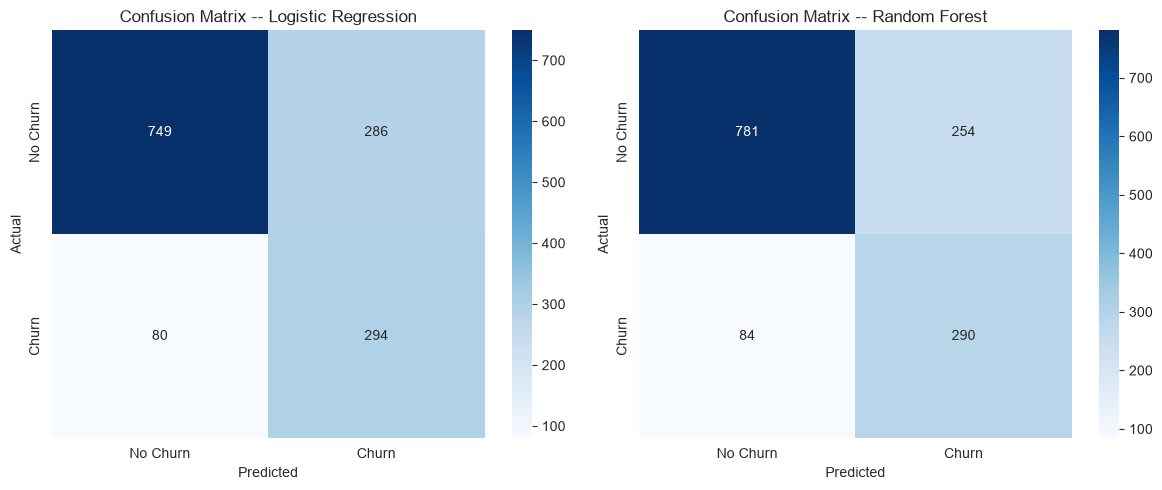

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, preds) in zip(axes, [("Logistic Regression", log_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"], ax=ax)
    ax.set_title(f"Confusion Matrix -- {name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


### Threshold analysis

Both models output a churn *probability*, and by default `.predict()` uses a 0.5 cutoff to turn that into Yes/No. But 0.5 isn't necessarily the right business cutoff. Since we care more about catching likely churners (recall) than being conservative, it's worth checking what happens at other thresholds. The 0.5 cutoff is only the default, so we'll compare other thresholds to see the effect on precision and recall.

In [25]:
def threshold_table(y_true, y_proba, thresholds=(0.30, 0.40, 0.50, 0.60)):
    rows = []
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        rows.append({
            "Threshold": t,
            "Precision": precision_score(y_true, preds),
            "Recall": recall_score(y_true, preds),
            "F1": f1_score(y_true, preds),
        })
    return pd.DataFrame(rows).round(3)

print("Random Forest -- threshold trade-off:")
rf_threshold_df = threshold_table(y_test, rf_proba)
rf_threshold_df


Random Forest -- threshold trade-off:


,Threshold,Precision,Recall,F1
0,0.3,0.437,0.896,0.587
1,0.4,0.495,0.853,0.627
2,0.5,0.533,0.775,0.632
3,0.6,0.576,0.666,0.618


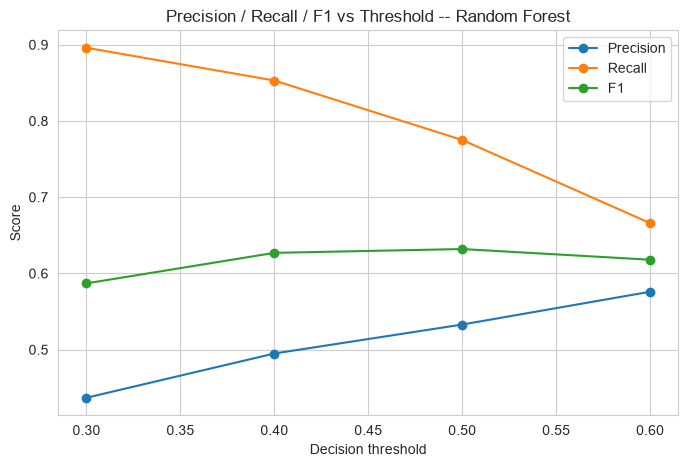

Finding: lowering the threshold below 0.5 catches more true churners (higher recall) at the cost of more false alarms (lower precision). A threshold around 0.3-0.4 is a reasonable choice for a retention campaign where the cost of a missed churner is higher than the cost of an unnecessary outreach call.


In [26]:
plt.figure()
plt.plot(rf_threshold_df["Threshold"], rf_threshold_df["Precision"], marker="o", label="Precision")
plt.plot(rf_threshold_df["Threshold"], rf_threshold_df["Recall"], marker="o", label="Recall")
plt.plot(rf_threshold_df["Threshold"], rf_threshold_df["F1"], marker="o", label="F1")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold -- Random Forest")
plt.legend()
plt.show()

print("Finding: lowering the threshold below 0.5 catches more true churners (higher recall) at the cost of "
      "more false alarms (lower precision). A threshold around 0.3-0.4 is a reasonable choice for a retention "
      "campaign where the cost of a missed churner is higher than the cost of an unnecessary outreach call.")


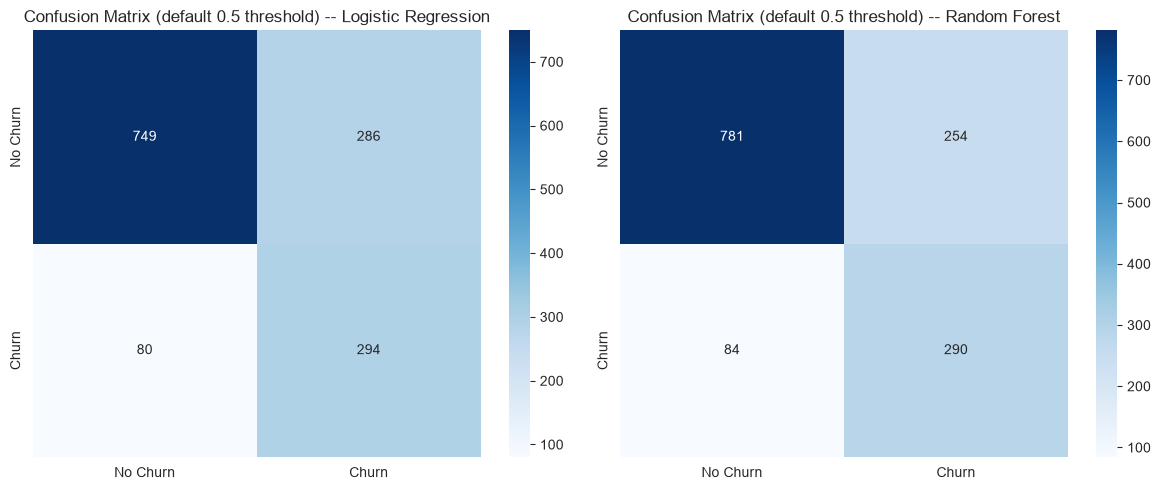

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, preds) in zip(axes, [("Logistic Regression", log_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"], ax=ax)
    ax.set_title(f"Confusion Matrix (default 0.5 threshold) -- {name}")
plt.tight_layout()
plt.show()


## 8. Feature importance

Which features drive the model's predictions? Feature names are pulled directly from the fitted `ColumnTransformer`, so they stay in sync with the pipeline automatically.

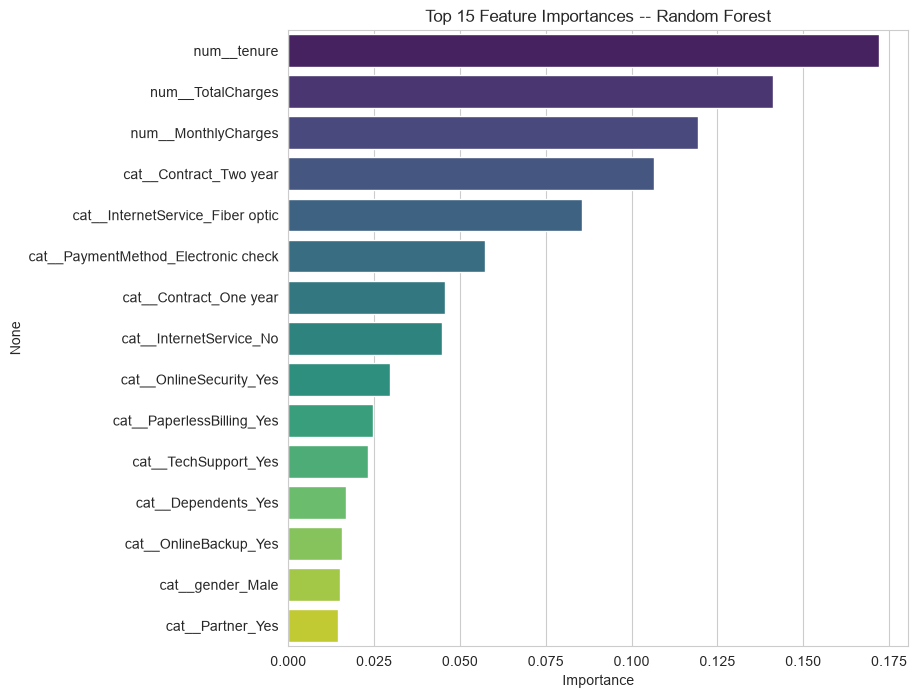

In [28]:
feature_names = rf_pipe.named_steps["preprocessor"].get_feature_names_out()
rf_importance = pd.Series(
    rf_pipe.named_steps["model"].feature_importances_, index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
top_n = 15
sns.barplot(x=rf_importance.head(top_n).values, y=rf_importance.head(top_n).index,
            hue=rf_importance.head(top_n).index, palette="viridis", legend=False)
plt.title(f"Top {top_n} Feature Importances -- Random Forest")
plt.xlabel("Importance")
plt.show()


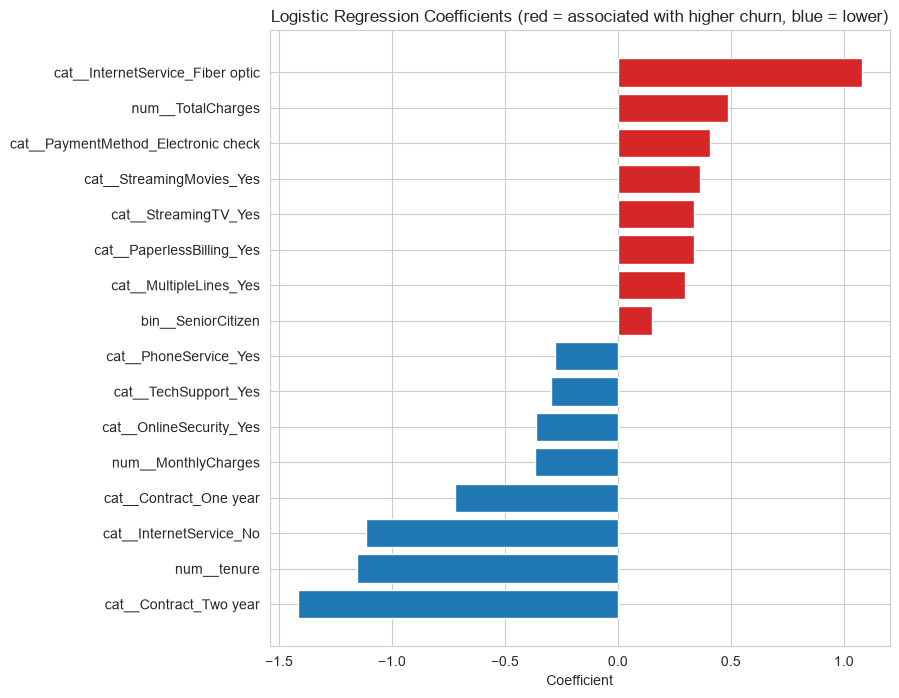

In [29]:
log_feature_names = log_pipe.named_steps["preprocessor"].get_feature_names_out()
log_coef = pd.Series(log_pipe.named_steps["model"].coef_[0], index=log_feature_names).sort_values()

plt.figure(figsize=(8, 8))
combined = pd.concat([log_coef.head(8), log_coef.tail(8)])
colors = ["#d62728" if v > 0 else "#1f77b4" for v in combined.values]
plt.barh(combined.index, combined.values, color=colors)
plt.title("Logistic Regression Coefficients (red = associated with higher churn, blue = lower)")
plt.xlabel("Coefficient")
plt.show()


## 9. Final model selection — evidence-based

Rather than picking a model by assumption, the decision below is driven directly by the metrics computed in Section 7.

In [30]:
print(f"Logistic Regression: Precision={log_precision:.3f}, Recall={log_recall:.3f}, F1={log_f1:.3f}")
print(f"Random Forest:       Precision={rf_precision:.3f}, Recall={rf_recall:.3f}, F1={rf_f1:.3f}")
print()

if rf_f1 >= log_f1:
    FINAL_MODEL = "random_forest"
    final_pipe, final_pred, final_proba = rf_pipe, rf_pred, rf_proba
    print(f"Decision: Random Forest selected as the final scoring model -- it achieves the stronger F1 "
          f"({rf_f1:.3f} vs {log_f1:.3f}) with a better precision/recall balance. Logistic Regression is "
          f"retained as the interpretable baseline for explaining direction of effects.")
else:
    FINAL_MODEL = "logistic_regression"
    final_pipe, final_pred, final_proba = log_pipe, log_pred, log_proba
    print(f"Decision: Logistic Regression selected as the final scoring model -- it achieves the stronger F1 "
          f"({log_f1:.3f} vs {rf_f1:.3f}). Random Forest is retained for its feature importance ranking.")


Logistic Regression: Precision=0.507, Recall=0.786, F1=0.616
Random Forest:       Precision=0.533, Recall=0.775, F1=0.632

Decision: Random Forest selected as the final scoring model -- it achieves the stronger F1 (0.632 vs 0.616) with a better precision/recall balance. Logistic Regression is retained as the interpretable baseline for explaining direction of effects.


## 10. Export for Power BI — four separate outputs

| File                              | Purpose                          |
| --------------------------------- | -------------------------------- |
| `churn_scoring_all_customers.csv` | Final customer risk scores       |
| `churn_eval_test_set.csv`         | Held-out test predictions        |
| `rf_feature_importance.csv`       | Random Forest feature importance |
| `lr_coefficients.csv`             | Logistic Regression coefficients |

The test-set file is used for model evaluation, while the full-customer file is used for Power BI scoring.

**Important:** dataset 1 must never be used to claim model accuracy — the model has seen those customers during its final fit. It's for business scoring/segmentation only. The real, defensible performance numbers live in dataset 2.

In [31]:
import os
os.makedirs("outputs", exist_ok=True)

# 1. Evaluation dataset -- test set only, from the already-fitted final_pipe
eval_df = data.loc[X_test.index, ["customerID"]].copy()
eval_df["ActualChurn"] = data.loc[X_test.index, "Churn"].values
eval_df["PredictedChurn"] = np.where(final_pred == 1, "Yes", "No")
eval_df["ChurnProbability"] = final_proba.round(4)

eval_df.to_csv("outputs/churn_eval_test_set.csv", index=False)
print(f"Saved churn_eval_test_set.csv -- {eval_df.shape[0]} rows (test set, for evaluation only)")
eval_df.head()


Saved churn_eval_test_set.csv -- 1409 rows (test set, for evaluation only)


,customerID,ActualChurn,PredictedChurn,ChurnProbability
437,4376-KFVRS,No,No,0.0212
2280,2754-SDJRD,No,Yes,0.8886
2235,9917-KWRBE,No,No,0.1439
4460,0365-GXEZS,No,Yes,0.5433
3761,9385-NXKDA,No,No,0.0442


In [32]:
# 2. Business scoring dataset -- refit the SAME pipeline architecture on ALL data, score every customer
production_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_pipe.named_steps["model"].__class__(**rf_pipe.named_steps["model"].get_params())
     if FINAL_MODEL == "random_forest"
     else log_pipe.named_steps["model"].__class__(**log_pipe.named_steps["model"].get_params())),
])
production_pipe.fit(X, y)

all_proba = production_pipe.predict_proba(X)[:, 1]
all_pred = production_pipe.predict(X)

# Keep every original customer attribute (plus the true Churn label) so the Power BI
# model has full flexibility for slicers -- gender, SeniorCitizen, Partner, etc.
scoring_cols = ["customerID", "gender", "SeniorCitizen", "Partner", "Dependents", "tenure",
                 "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
                 "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
                 "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod",
                 "MonthlyCharges", "TotalCharges", "Churn"]
scoring_df = data[scoring_cols].copy()
scoring_df["PredictedChurn"] = np.where(all_pred == 1, "Yes", "No")
scoring_df["ChurnProbability"] = all_proba.round(4)
scoring_df["HighRisk"] = np.where(scoring_df["ChurnProbability"] >= 0.40, "Yes", "No")

os.makedirs(f"{dir}\\outputs", exist_ok=True)
scoring_df.to_csv(f"{dir}\\outputs\\churn_scoring_all_customers.csv", index=False)
print(f"Saved churn_scoring_all_customers.csv -- {scoring_df.shape[0]} rows, {scoring_df.shape[1]} columns "
      f"(ALL customers, for business scoring -- keeps actual Churn for dynamic actual-rate calculations)")
scoring_df.sort_values("ChurnProbability", ascending=False).head()


Saved churn_scoring_all_customers.csv -- 7043 rows, 24 columns (ALL customers, for business scoring -- keeps actual Churn for dynamic actual-rate calculations)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PredictedChurn,ChurnProbability,HighRisk
2208,7216-EWTRS,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.80,100.80,Yes,Yes,0.9579,Yes
3380,5178-LMXOP,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.10,95.10,Yes,Yes,0.9569,Yes
1976,9497-QCMMS,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,93.55,93.55,Yes,Yes,0.9558,Yes
4800,9300-AGZNL,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.00,94.00,Yes,Yes,0.9558,Yes
6482,5419-JPRRN,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,101.45,101.45,Yes,Yes,0.9546,Yes


In [33]:
feat_imp_df = rf_importance.reset_index()
feat_imp_df.columns = ["Feature", "Importance"]
feat_imp_df.to_csv("outputs/rf_feature_importance.csv", index=False)
print(f"Saved rf_feature_importance.csv -- {feat_imp_df.shape[0]} rows")
feat_imp_df.head(10)


Saved rf_feature_importance.csv -- 23 rows


,Feature,Importance
0,num__tenure,0.171997
1,num__TotalCharges,0.141204
2,num__MonthlyCharges,0.119467
3,cat__Contract_Two year,0.106400
4,cat__InternetService_Fiber optic,0.085528
5,cat__PaymentMethod_Electronic check,0.057152
6,cat__Contract_One year,0.045541
7,cat__InternetService_No,0.044700
8,cat__OnlineSecurity_Yes,0.029566
9,cat__PaperlessBilling_Yes,0.024599


In [34]:
lr_coef_df = log_coef.reset_index()
lr_coef_df.columns = ["Feature", "Coefficient"]
lr_coef_df["Direction"] = np.where(lr_coef_df["Coefficient"] > 0, "Associated with higher churn", "Associated with lower churn")
os.makedirs(f"{dir}\\outputs", exist_ok=True)
lr_coef_df.to_csv(f"{dir}\\outputs\\lr_coefficients.csv", index=False)
print(f"Saved lr_coefficients.csv -- {lr_coef_df.shape[0]} rows")
lr_coef_df.sort_values("Coefficient", ascending=False).head(10)


Saved lr_coefficients.csv -- 23 rows


,Feature,Coefficient,Direction
22,cat__InternetService_Fiber optic,1.078480,Associated with higher churn
21,num__TotalCharges,0.485826,Associated with higher churn
20,cat__PaymentMethod_Electronic check,0.405849,Associated with higher churn
19,cat__StreamingMovies_Yes,0.363801,Associated with higher churn
18,cat__StreamingTV_Yes,0.338624,Associated with higher churn
17,cat__PaperlessBilling_Yes,0.338541,Associated with higher churn
16,cat__MultipleLines_Yes,0.295516,Associated with higher churn
15,bin__SeniorCitizen,0.153185,Associated with higher churn
14,cat__PaymentMethod_Mailed check,0.053353,Associated with higher churn
13,cat__gender_Male,0.032086,Associated with higher churn


## Summary / business takeaways

* Churn is highest among **month-to-month customers**, **customers with shorter tenure**, and **fiber optic / electronic-check customers**.
* The interaction analysis shows that the tenure pattern is still visible within the different contract types, and the higher churn among fiber customers is also visible across contract groups.
* The default **0.5 probability threshold** gives a reasonable balance, but lowering it to around **0.3–0.4** increases recall and identifies more potential churners.
* For a retention use case, a lower threshold could be useful if the goal is to find more customers who might leave, even if some of the predictions are false positives.
* The final predictions will be used in **Power BI** to explore customer risk and the main churn patterns.
